<a href="https://colab.research.google.com/github/SHREYA-G-AMIN/Agentic-AI/blob/main/Day_4_Image_to_Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q openai pillow

In [2]:
from google.colab import userdata, files
from PIL import Image
import base64
from io import BytesIO
import openai

In [4]:
# -----------------------------
# API Configuration
# -----------------------------
api_key = userdata.get("nanokey")

client = openai.OpenAI(
    api_key=api_key,
    base_url="https://nexusapi.navigatelabs.ai"
)

Saving aadish.jpg to aadish.jpg


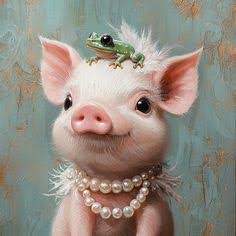

In [5]:
# -----------------------------
# Upload Image
# -----------------------------
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Display the uploaded image
img = Image.open(image_path)
display(img)

In [6]:
# -----------------------------
# Ask user for a question
# -----------------------------
question = input("Ask a question about the uploaded image: ")

# -----------------------------
# Convert image to Base64
# -----------------------------
with open(image_path, "rb") as f:
    image_base64 = base64.b64encode(f.read()).decode("utf-8")

Ask a question about the uploaded image: describe the image


In [8]:
# -----------------------------
# Send Image + Text to Model
# -----------------------------
response = client.chat.completions.create(
    model="gpt-4.1-nano",   # Use your vision-capable model
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": question
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{image_base64}"
                    }
                }
            ]
        }
    ]
)

print("\nModel Response:\n")
print(response.choices[0].message.content)


Model Response:

The image features an adorable piglet wearing a string of pearls around its neck, giving it a fancy appearance. On top of the piglet's head, there is a small green frog sitting, adding a cute and whimsical touch to the scene. The background is a soft, muted color, which highlights the charming subject in the foreground.
